# DIVA Dataset - Image Diversity Analysis


## Methods

- Grayscale Variance
- RGB PCA
- RGB ICA


## Imports

In [1]:
# Import Required Libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## Config

In [2]:
# ============ ADJUSTABLE PARAMETERS ============
DIVA_SUBSET = "CB55"  # "CB55", "CS18", or "CS863"
NUM_DIVERSE_IMAGES = 5  # Number of images to select for each method
USE_RGB_VARIANCE = True  # If False, use grayscale variance
# ============================================

print(f"Configuration:")
print(f"  Dataset subset: {DIVA_SUBSET}")
print(f"  Number of diverse images to select: {NUM_DIVERSE_IMAGES}")
print(f"  Use RGB variance: {USE_RGB_VARIANCE}")

Configuration:
  Dataset subset: CB55
  Number of diverse images to select: 5
  Use RGB variance: True


## Load Dataset

In [3]:
# DIVA dataset paths (using configured subset)
DIVA_BASE_PATH = Path("../00_data/DIVA-HisDB")
DIVA_SUBSET_PATH = DIVA_BASE_PATH / DIVA_SUBSET / f"img-{DIVA_SUBSET}" / "img"

# Find all images in the dataset
all_images = []
for split in ["public-test", "public-train"]:
    split_path = DIVA_SUBSET_PATH / split
    if split_path.exists():
        images = list(split_path.glob("*.jpg")) + list(split_path.glob("*.png"))
        all_images.extend(images)
        print(f"Found {len(images)} images in {split}")

print(f"\nTotal images: {len(all_images)}")

# Use training images if available, otherwise use all
train_images = list((DIVA_SUBSET_PATH / "public-train").glob("*.jpg")) + list((DIVA_SUBSET_PATH / "public-train").glob("*.png"))
if train_images:
    images_to_analyze = train_images
    split_name = "public-train"
else:
    images_to_analyze = all_images
    split_name = "all"

print(f"Using {len(images_to_analyze)} images from {split_name}")
images_to_analyze = sorted(images_to_analyze)

Found 10 images in public-test

Total images: 10
Using 10 images from all


## Feature Extraction

In [4]:
# Load pre-trained ResNet18 model for feature extraction
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load ResNet18 (remove final layer for feature extraction)
model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])  # Remove classification layer
model = model.to(device)
model.eval()

# Image preprocessing
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((720, 720)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# Extract features from all images
features_list = []
valid_images = []

print(f"\nExtracting features from {len(images_to_analyze)} images...")
for img_path in tqdm(images_to_analyze, desc="Feature extraction"):
    try:
        # Load and preprocess image
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = preprocess(img_rgb).unsqueeze(0).to(device)
        
        # Extract features
        with torch.no_grad():
            features = model(img_tensor)
            features = features.squeeze().cpu().numpy().flatten()
        
        features_list.append(features)
        valid_images.append(img_path)
    except Exception as e:
        continue

print(f"Successfully extracted features from {len(features_list)} images")

# Convert to numpy array
features_array = np.array(features_list)
print(f"Feature matrix shape: {features_array.shape}")

Using device: cuda

Extracting features from 10 images...


Feature extraction: 100%|██████████| 10/10 [00:02<00:00,  3.34it/s]

Successfully extracted features from 10 images
Feature matrix shape: (10, 512)


## Method 1: Grayscale Variance

In [5]:
# Calculate grayscale variance for each image
variance_list = []

print("Calculating grayscale variance for all images...")
for img_path in tqdm(valid_images, desc="Grayscale variance"):
    img = cv2.imread(str(img_path))
    if img is None:
        variance_list.append(0)
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    var = np.var(gray)
    variance_list.append(var)

variance_array = np.array(variance_list)
top_var_indices = np.argsort(variance_array)[-NUM_DIVERSE_IMAGES:][::-1]

print(f"\nTop {NUM_DIVERSE_IMAGES} images by grayscale variance:")
for idx in top_var_indices:
    print(f"  Image {idx}: {valid_images[idx].name} (variance: {variance_array[idx]:.2f})")

Calculating grayscale variance for all images...


Grayscale variance: 100%|██████████| 10/10 [00:01<00:00,  6.33it/s]


Top 5 images by grayscale variance:
  Image 1: e-codices_fmb-cb-0055_0099v_max.jpg (variance: 7333.80)
  Image 4: e-codices_fmb-cb-0055_0107v_max.jpg (variance: 7194.95)
  Image 0: e-codices_fmb-cb-0055_0098v_max.jpg (variance: 7084.07)
  Image 6: e-codices_fmb-cb-0055_0116r_max.jpg (variance: 7058.23)
  Image 3: e-codices_fmb-cb-0055_0105r_max.jpg (variance: 7049.13)


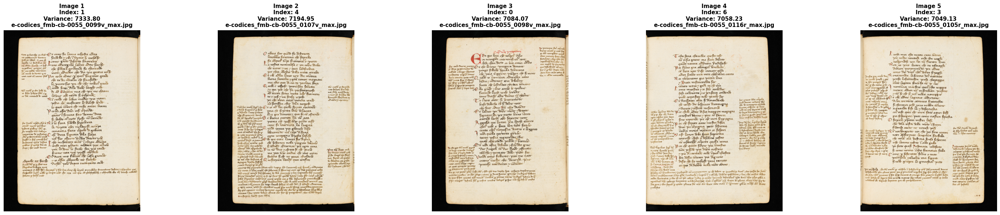

Saved as 'diva_cb55_grayscale_variance.png'


In [6]:
# Display images with highest grayscale variance
fig, axes = plt.subplots(1, NUM_DIVERSE_IMAGES, figsize=(6*NUM_DIVERSE_IMAGES, 6))

# Handle case when NUM_DIVERSE_IMAGES == 1
if NUM_DIVERSE_IMAGES == 1:
    axes = [axes]

for idx, img_idx in enumerate(top_var_indices):
    img_path = valid_images[img_idx]
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[idx].imshow(img_rgb)
    axes[idx].set_title(f"Image {idx+1}\nIndex: {img_idx}\nVariance: {variance_array[img_idx]:.2f}\n{img_path.name}", 
                       fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(f"diva_{DIVA_SUBSET.lower()}_grayscale_variance.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved as 'diva_{DIVA_SUBSET.lower()}_grayscale_variance.png'")

## Method 2: RGB PCA (Principal Component Analysis)

## Diversity Selection (PCA)

In [7]:
# --- RGB PCA: Project Features to 2D ---
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_array)

pca = PCA(n_components=2)
features_2d = pca.fit_transform(features_scaled)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")
print(f"2D feature matrix shape (PCA): {features_2d.shape}")

PCA explained variance ratio: [0.38416398 0.15347584]
Total variance explained: 0.5376
2D feature matrix shape (PCA): (10, 2)


In [8]:
# Calculate pairwise distances in 2D space
distances = euclidean_distances(features_2d)

# Find the N images with the highest pairwise distances
print(f"Searching for {NUM_DIVERSE_IMAGES} images with highest diversity...")

# Get all pairwise distances and sort them
distance_pairs = []
for i in range(len(features_2d)):
    for j in range(i + 1, len(features_2d)):
        distance_pairs.append((distances[i, j], i, j))

distance_pairs.sort(reverse=True)

# Strategy: For each possible combination, find the set with maximum minimum distance
from itertools import combinations

best_combination = None
best_min_distance = 0

# Generate all combinations of NUM_DIVERSE_IMAGES images
for combo in combinations(range(len(features_2d)), NUM_DIVERSE_IMAGES):
    # Calculate minimum distance in this combination
    min_dist = float('inf')
    for i in range(len(combo)):
        for j in range(i + 1, len(combo)):
            dist = distances[combo[i], combo[j]]
            min_dist = min(min_dist, dist)
    
    # Update best combination if this one is better
    if min_dist > best_min_distance:
        best_min_distance = min_dist
        best_combination = combo

selected_indices = best_combination
print(f"Selected image indices: {selected_indices}")
print(f"Minimum pairwise distance: {best_min_distance:.4f}")

# Print distances between selected images
print("\nPairwise distances:")
for i in range(len(selected_indices)):
    for j in range(i + 1, len(selected_indices)):
        idx1, idx2 = selected_indices[i], selected_indices[j]
        dist = distances[idx1, idx2]
        print(f"  Distance between image {idx1} and {idx2}: {dist:.4f}")

Searching for 5 images with highest diversity...
Selected image indices: (0, 2, 6, 8, 9)
Minimum pairwise distance: 10.7994

Pairwise distances:
  Distance between image 0 and 2: 25.8276
  Distance between image 0 and 6: 10.7994
  Distance between image 0 and 8: 13.1280
  Distance between image 0 and 9: 28.6553
  Distance between image 2 and 6: 26.6274
  Distance between image 2 and 8: 16.6935
  Distance between image 2 and 9: 47.5322
  Distance between image 6 and 8: 20.3865
  Distance between image 6 and 9: 38.7873
  Distance between image 8 and 9: 30.9259


## Visualize PCA

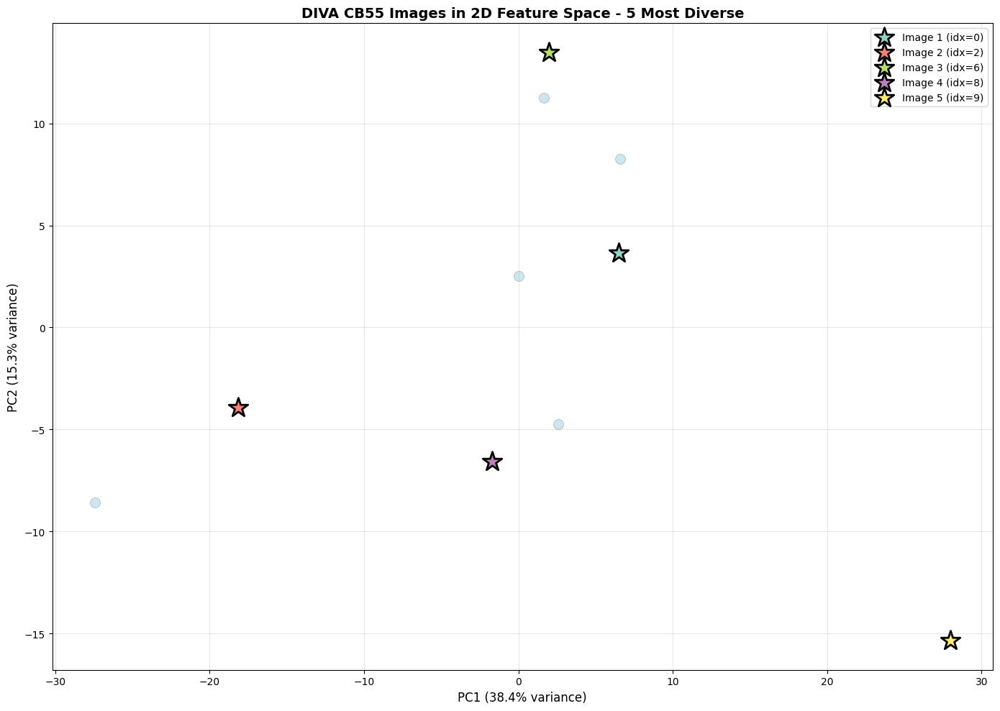

2D scatter plot saved as 'diva_cb55_2d_scatter.png'


In [9]:
# Create scatter plot with all images
fig, ax = plt.subplots(figsize=(14, 10))

# Plot all images
scatter = ax.scatter(features_2d[:, 0], features_2d[:, 1], 
                     c='lightblue', s=100, alpha=0.6, edgecolors='gray', linewidth=0.5)

# Generate colors for selected images
colors = plt.cm.Set3(np.linspace(0, 1, NUM_DIVERSE_IMAGES))

# Highlight the selected images
for idx, (color, img_idx) in enumerate(zip(colors, selected_indices)):
    ax.scatter(features_2d[img_idx, 0], features_2d[img_idx, 1], 
              s=400, color=color, marker='*', edgecolors='black', linewidth=2,
              label=f"Image {idx+1} (idx={img_idx})")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=12)
ax.set_title(f"DIVA {DIVA_SUBSET} Images in 2D Feature Space - {NUM_DIVERSE_IMAGES} Most Diverse", 
            fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"diva_{DIVA_SUBSET.lower()}_2d_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"2D scatter plot saved as 'diva_{DIVA_SUBSET.lower()}_2d_scatter.png'")

## Show Selected (PCA)

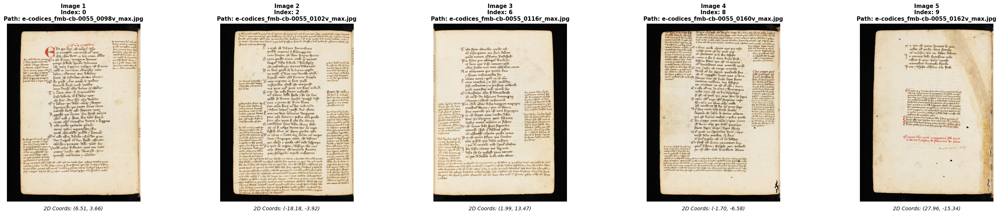

Selected images saved as 'diva_cb55_selected_images.png'

Selected image paths:
  Image 1: ../00_data/DIVA-HisDB/CB55/img-CB55/img/public-test/e-codices_fmb-cb-0055_0098v_max.jpg
  Image 2: ../00_data/DIVA-HisDB/CB55/img-CB55/img/public-test/e-codices_fmb-cb-0055_0102v_max.jpg
  Image 3: ../00_data/DIVA-HisDB/CB55/img-CB55/img/public-test/e-codices_fmb-cb-0055_0116r_max.jpg
  Image 4: ../00_data/DIVA-HisDB/CB55/img-CB55/img/public-test/e-codices_fmb-cb-0055_0160v_max.jpg
  Image 5: ../00_data/DIVA-HisDB/CB55/img-CB55/img/public-test/e-codices_fmb-cb-0055_0162v_max.jpg


In [10]:
# Display the selected images
fig, axes = plt.subplots(1, NUM_DIVERSE_IMAGES, figsize=(6*NUM_DIVERSE_IMAGES, 6))

# Handle case when NUM_DIVERSE_IMAGES == 1
if NUM_DIVERSE_IMAGES == 1:
    axes = [axes]

for idx, img_idx in enumerate(selected_indices):
    img_path = valid_images[img_idx]
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    axes[idx].imshow(img_rgb)
    axes[idx].set_title(f"Image {idx+1}\nIndex: {img_idx}\nPath: {img_path.name}", fontsize=11, fontweight='bold')
    axes[idx].axis('off')
    
    # Add 2D coordinates as text
    coords_text = f"2D Coords: ({features_2d[img_idx, 0]:.2f}, {features_2d[img_idx, 1]:.2f})"
    axes[idx].text(0.5, -0.05, coords_text, transform=axes[idx].transAxes, 
                  ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig(f"diva_{DIVA_SUBSET.lower()}_selected_images.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Selected images saved as 'diva_{DIVA_SUBSET.lower()}_selected_images.png'")
print(f"\nSelected image paths:")
for idx, img_idx in enumerate(selected_indices, 1):
    print(f"  Image {idx}: {valid_images[img_idx]}")

In [11]:
# Calculate centroid in PCA space and find images furthest from it
pca_centroid = np.mean(features_2d, axis=0)
pca_centroid_dists = np.linalg.norm(features_2d - pca_centroid, axis=1)
pca_centroid_indices = np.argsort(pca_centroid_dists)[-NUM_DIVERSE_IMAGES:][::-1]

print(f"PCA Centroid: ({pca_centroid[0]:.2f}, {pca_centroid[1]:.2f})")
print(f"\nTop {NUM_DIVERSE_IMAGES} images furthest from centroid (PCA):")
for idx in pca_centroid_indices:
    print(f"  Image {idx}: {valid_images[idx].name} (distance: {pca_centroid_dists[idx]:.2f})")

PCA Centroid: (-0.00, 0.00)

Top 5 images furthest from centroid (PCA):
  Image 9: e-codices_fmb-cb-0055_0162v_max.jpg (distance: 31.89)
  Image 5: e-codices_fmb-cb-0055_0108v_max.jpg (distance: 28.74)
  Image 2: e-codices_fmb-cb-0055_0102v_max.jpg (distance: 18.60)
  Image 6: e-codices_fmb-cb-0055_0116r_max.jpg (distance: 13.61)
  Image 3: e-codices_fmb-cb-0055_0105r_max.jpg (distance: 11.37)


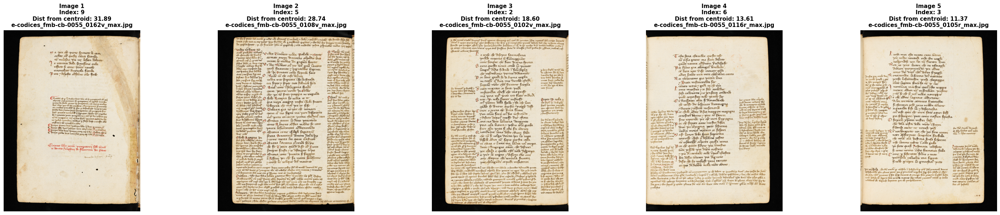

PCA centroid images saved as 'diva_cb55_pca_centroid_images.png'


In [12]:
# Display selected images from PCA centroid method
fig, axes = plt.subplots(1, NUM_DIVERSE_IMAGES, figsize=(6*NUM_DIVERSE_IMAGES, 6))

# Handle case when NUM_DIVERSE_IMAGES == 1
if NUM_DIVERSE_IMAGES == 1:
    axes = [axes]

for idx, img_idx in enumerate(pca_centroid_indices):
    img_path = valid_images[img_idx]
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    axes[idx].imshow(img_rgb)
    axes[idx].set_title(f"Image {idx+1}\nIndex: {img_idx}\nDist from centroid: {pca_centroid_dists[img_idx]:.2f}\n{img_path.name}", 
                       fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(f"diva_{DIVA_SUBSET.lower()}_pca_centroid_images.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"PCA centroid images saved as 'diva_{DIVA_SUBSET.lower()}_pca_centroid_images.png'")

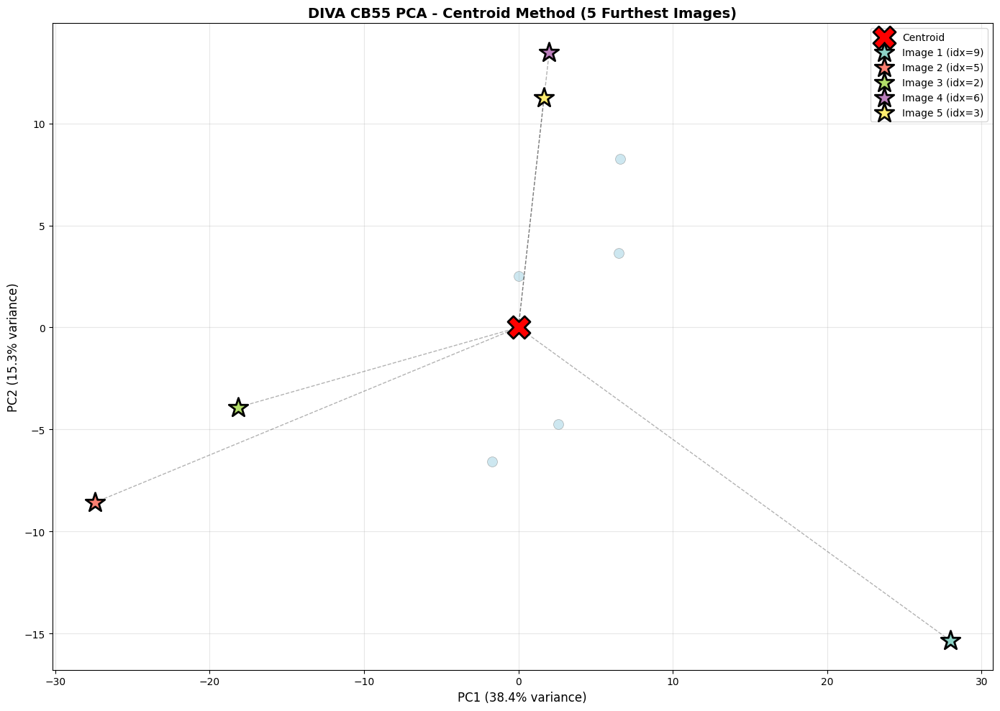

PCA centroid plot saved as 'diva_cb55_pca_centroid.png'


In [13]:
# Visualize PCA space with centroid selection
fig, ax = plt.subplots(figsize=(14, 10))

# Plot all images
ax.scatter(features_2d[:, 0], features_2d[:, 1], 
          c='lightblue', s=100, alpha=0.6, edgecolors='gray', linewidth=0.5)

# Plot centroid
ax.scatter(pca_centroid[0], pca_centroid[1], 
          s=500, color='red', marker='X', edgecolors='black', linewidth=2,
          label='Centroid', zorder=5)

# Generate colors for selected images
colors = plt.cm.Set3(np.linspace(0, 1, NUM_DIVERSE_IMAGES))

# Highlight the selected images and draw lines to centroid
for idx, (color, img_idx) in enumerate(zip(colors, pca_centroid_indices)):
    ax.scatter(features_2d[img_idx, 0], features_2d[img_idx, 1], 
              s=400, color=color, marker='*', edgecolors='black', linewidth=2,
              label=f"Image {idx+1} (idx={img_idx})", zorder=4)
    # Draw line from centroid to selected image
    ax.plot([pca_centroid[0], features_2d[img_idx, 0]], 
           [pca_centroid[1], features_2d[img_idx, 1]], 
           'k--', alpha=0.3, linewidth=1)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=12)
ax.set_title(f"DIVA {DIVA_SUBSET} PCA - Centroid Method ({NUM_DIVERSE_IMAGES} Furthest Images)", 
            fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"diva_{DIVA_SUBSET.lower()}_pca_centroid.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"PCA centroid plot saved as 'diva_{DIVA_SUBSET.lower()}_pca_centroid.png'")

### Centroid Distance Method (PCA)

## Method 3: RGB ICA (Independent Component Analysis)

In [14]:
# Apply ICA to project features to 2D
from sklearn.decomposition import FastICA

ica = FastICA(n_components=2, random_state=42)
features_ica_2d = ica.fit_transform(features_scaled)
print(f'2D feature matrix shape (ICA): {features_ica_2d.shape}')

# Calculate pairwise distances in ICA space
ica_distances = euclidean_distances(features_ica_2d)
ica_distance_pairs = []
for i in range(len(features_ica_2d)):
    for j in range(i + 1, len(features_ica_2d)):
        ica_distance_pairs.append((ica_distances[i, j], i, j))

ica_distance_pairs.sort(reverse=True)

# Select most diverse images using greedy approach
if NUM_DIVERSE_IMAGES == 1:
    ica_max_dist_indices = [ica_distance_pairs[0][1]]
else:
    ica_max_dist_indices = [ica_distance_pairs[0][1], ica_distance_pairs[0][2]]
    if NUM_DIVERSE_IMAGES > 2:
        used = set(ica_max_dist_indices)
        for dist, i, j in ica_distance_pairs[1:]:
            if i not in used:
                ica_max_dist_indices.append(i)
                used.add(i)
            if j not in used and len(ica_max_dist_indices) < NUM_DIVERSE_IMAGES:
                ica_max_dist_indices.append(j)
                used.add(j)
            if len(ica_max_dist_indices) >= NUM_DIVERSE_IMAGES:
                break

print(f'\nTop {NUM_DIVERSE_IMAGES} images by max pairwise distance (ICA):')
for idx in ica_max_dist_indices:
    print(f"  Image {idx}: {valid_images[idx].name}")

2D feature matrix shape (ICA): (10, 2)

Top 5 images by max pairwise distance (ICA):
  Image 5: e-codices_fmb-cb-0055_0108v_max.jpg
  Image 9: e-codices_fmb-cb-0055_0162v_max.jpg
  Image 6: e-codices_fmb-cb-0055_0116r_max.jpg
  Image 3: e-codices_fmb-cb-0055_0105r_max.jpg
  Image 2: e-codices_fmb-cb-0055_0102v_max.jpg


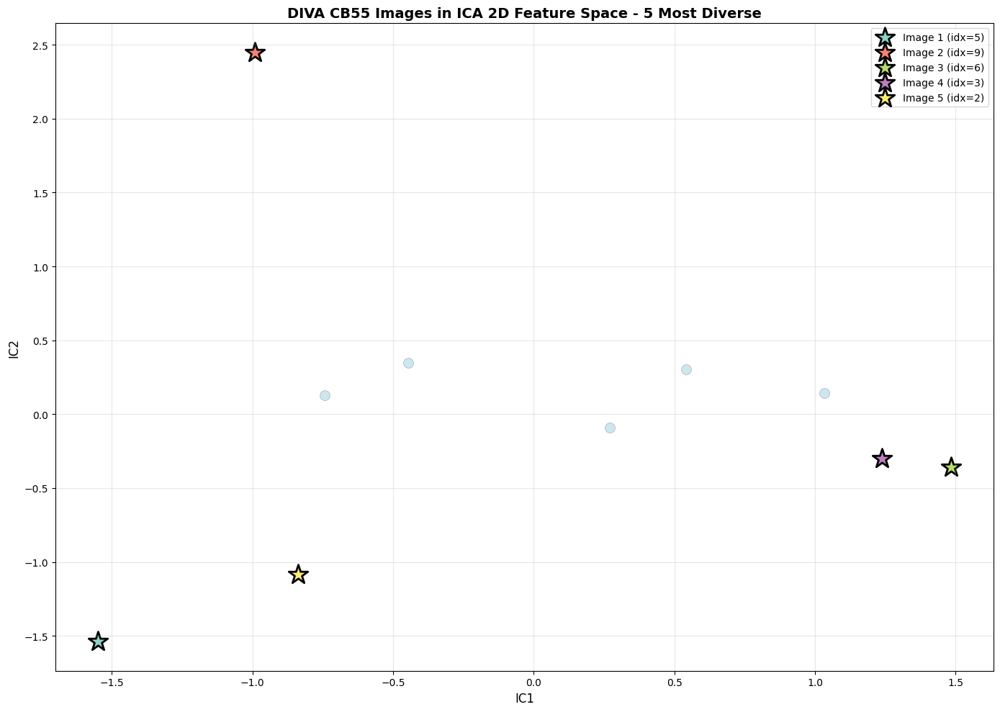

ICA 2D scatter plot saved as 'diva_cb55_ica_2d_scatter.png'


In [15]:
# Create scatter plot for ICA space
fig, ax = plt.subplots(figsize=(14, 10))

# Plot all images
ax.scatter(features_ica_2d[:, 0], features_ica_2d[:, 1], 
          c='lightblue', s=100, alpha=0.6, edgecolors='gray', linewidth=0.5)

# Generate colors for selected images
colors = plt.cm.Set3(np.linspace(0, 1, NUM_DIVERSE_IMAGES))

# Highlight the selected images
for idx, (color, img_idx) in enumerate(zip(colors, ica_max_dist_indices)):
    ax.scatter(features_ica_2d[img_idx, 0], features_ica_2d[img_idx, 1], 
              s=400, color=color, marker='*', edgecolors='black', linewidth=2,
              label=f"Image {idx+1} (idx={img_idx})")

ax.set_xlabel("IC1", fontsize=12)
ax.set_ylabel("IC2", fontsize=12)
ax.set_title(f"DIVA {DIVA_SUBSET} Images in ICA 2D Feature Space - {NUM_DIVERSE_IMAGES} Most Diverse", 
            fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"diva_{DIVA_SUBSET.lower()}_ica_2d_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"ICA 2D scatter plot saved as 'diva_{DIVA_SUBSET.lower()}_ica_2d_scatter.png'")

### Visualize ICA 2D Space

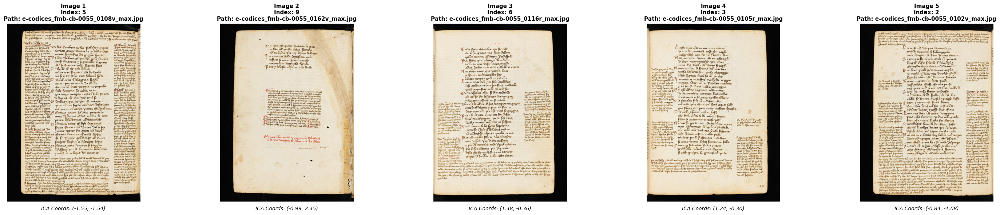

ICA selected images saved as 'diva_cb55_ica_selected_images.png'

Selected image paths:
  Image 1: ../00_data/DIVA-HisDB/CB55/img-CB55/img/public-test/e-codices_fmb-cb-0055_0108v_max.jpg
  Image 2: ../00_data/DIVA-HisDB/CB55/img-CB55/img/public-test/e-codices_fmb-cb-0055_0162v_max.jpg
  Image 3: ../00_data/DIVA-HisDB/CB55/img-CB55/img/public-test/e-codices_fmb-cb-0055_0116r_max.jpg
  Image 4: ../00_data/DIVA-HisDB/CB55/img-CB55/img/public-test/e-codices_fmb-cb-0055_0105r_max.jpg
  Image 5: ../00_data/DIVA-HisDB/CB55/img-CB55/img/public-test/e-codices_fmb-cb-0055_0102v_max.jpg


In [16]:
# Display the selected ICA images
fig, axes = plt.subplots(1, NUM_DIVERSE_IMAGES, figsize=(6*NUM_DIVERSE_IMAGES, 6))

# Handle case when NUM_DIVERSE_IMAGES == 1
if NUM_DIVERSE_IMAGES == 1:
    axes = [axes]

for idx, img_idx in enumerate(ica_max_dist_indices):
    img_path = valid_images[img_idx]
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    axes[idx].imshow(img_rgb)
    axes[idx].set_title(f"Image {idx+1}\nIndex: {img_idx}\nPath: {img_path.name}", fontsize=11, fontweight='bold')
    axes[idx].axis('off')
    
    # Add 2D coordinates as text
    coords_text = f"ICA Coords: ({features_ica_2d[img_idx, 0]:.2f}, {features_ica_2d[img_idx, 1]:.2f})"
    axes[idx].text(0.5, -0.05, coords_text, transform=axes[idx].transAxes, 
                  ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig(f"diva_{DIVA_SUBSET.lower()}_ica_selected_images.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"ICA selected images saved as 'diva_{DIVA_SUBSET.lower()}_ica_selected_images.png'")
print(f"\nSelected image paths:")
for idx, img_idx in enumerate(ica_max_dist_indices, 1):
    print(f"  Image {idx}: {valid_images[img_idx]}")

In [17]:
# Calculate centroid in ICA space and find images furthest from it
ica_centroid = np.mean(features_ica_2d, axis=0)
ica_centroid_dists = np.linalg.norm(features_ica_2d - ica_centroid, axis=1)
ica_centroid_indices = np.argsort(ica_centroid_dists)[-NUM_DIVERSE_IMAGES:][::-1]

print(f"ICA Centroid: ({ica_centroid[0]:.2f}, {ica_centroid[1]:.2f})")
print(f"\nTop {NUM_DIVERSE_IMAGES} images furthest from centroid (ICA):")
for idx in ica_centroid_indices:
    print(f"  Image {idx}: {valid_images[idx].name} (distance: {ica_centroid_dists[idx]:.2f})")

ICA Centroid: (0.00, 0.00)

Top 5 images furthest from centroid (ICA):
  Image 9: e-codices_fmb-cb-0055_0162v_max.jpg (distance: 2.64)
  Image 5: e-codices_fmb-cb-0055_0108v_max.jpg (distance: 2.18)
  Image 6: e-codices_fmb-cb-0055_0116r_max.jpg (distance: 1.53)
  Image 2: e-codices_fmb-cb-0055_0102v_max.jpg (distance: 1.37)
  Image 3: e-codices_fmb-cb-0055_0105r_max.jpg (distance: 1.27)


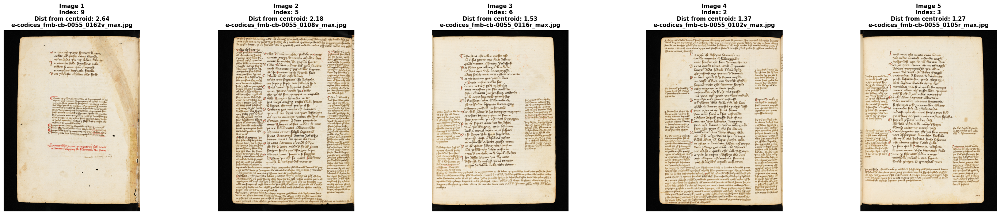

ICA centroid images saved as 'diva_cb55_ica_centroid_images.png'


In [18]:
# Display selected images from ICA centroid method
fig, axes = plt.subplots(1, NUM_DIVERSE_IMAGES, figsize=(6*NUM_DIVERSE_IMAGES, 6))

# Handle case when NUM_DIVERSE_IMAGES == 1
if NUM_DIVERSE_IMAGES == 1:
    axes = [axes]

for idx, img_idx in enumerate(ica_centroid_indices):
    img_path = valid_images[img_idx]
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    axes[idx].imshow(img_rgb)
    axes[idx].set_title(f"Image {idx+1}\nIndex: {img_idx}\nDist from centroid: {ica_centroid_dists[img_idx]:.2f}\n{img_path.name}", 
                       fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(f"diva_{DIVA_SUBSET.lower()}_ica_centroid_images.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"ICA centroid images saved as 'diva_{DIVA_SUBSET.lower()}_ica_centroid_images.png'")

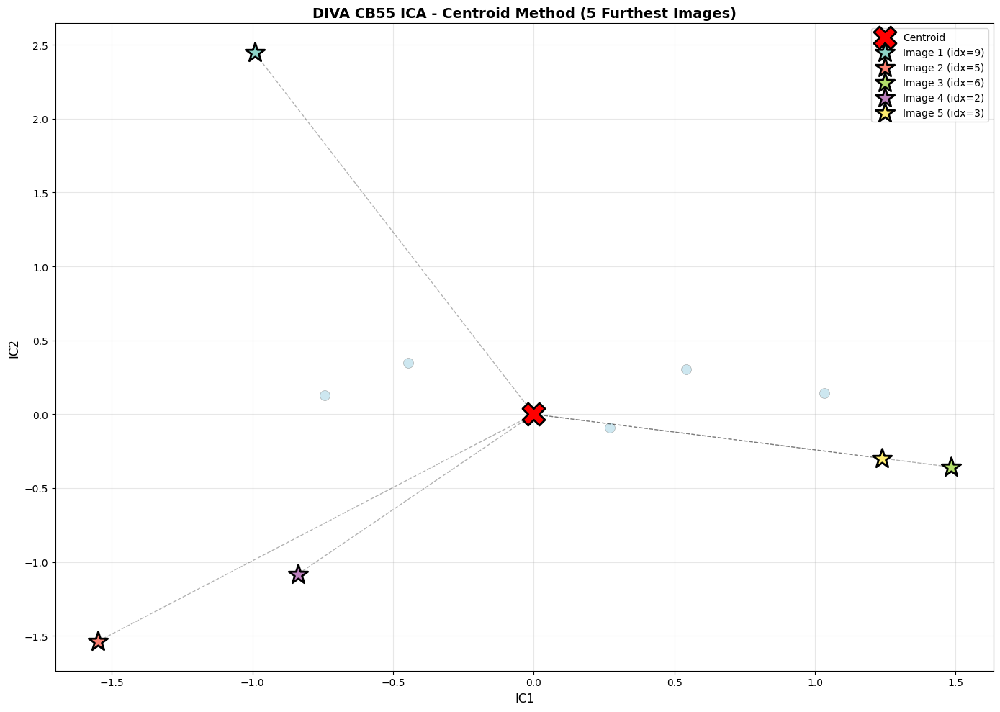

ICA centroid plot saved as 'diva_cb55_ica_centroid.png'


In [19]:
# Visualize ICA space with centroid selection
fig, ax = plt.subplots(figsize=(14, 10))

# Plot all images
ax.scatter(features_ica_2d[:, 0], features_ica_2d[:, 1], 
          c='lightblue', s=100, alpha=0.6, edgecolors='gray', linewidth=0.5)

# Plot centroid
ax.scatter(ica_centroid[0], ica_centroid[1], 
          s=500, color='red', marker='X', edgecolors='black', linewidth=2,
          label='Centroid', zorder=5)

# Generate colors for selected images
colors = plt.cm.Set3(np.linspace(0, 1, NUM_DIVERSE_IMAGES))

# Highlight the selected images and draw lines to centroid
for idx, (color, img_idx) in enumerate(zip(colors, ica_centroid_indices)):
    ax.scatter(features_ica_2d[img_idx, 0], features_ica_2d[img_idx, 1], 
              s=400, color=color, marker='*', edgecolors='black', linewidth=2,
              label=f"Image {idx+1} (idx={img_idx})", zorder=4)
    # Draw line from centroid to selected image
    ax.plot([ica_centroid[0], features_ica_2d[img_idx, 0]], 
           [ica_centroid[1], features_ica_2d[img_idx, 1]], 
           'k--', alpha=0.3, linewidth=1)

ax.set_xlabel("IC1", fontsize=12)
ax.set_ylabel("IC2", fontsize=12)
ax.set_title(f"DIVA {DIVA_SUBSET} ICA - Centroid Method ({NUM_DIVERSE_IMAGES} Furthest Images)", 
            fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"diva_{DIVA_SUBSET.lower()}_ica_centroid.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"ICA centroid plot saved as 'diva_{DIVA_SUBSET.lower()}_ica_centroid.png'")

In [20]:
print(f"\nSelected images")
print (f"Grayscale variance method:")
for idx in top_var_indices:
    print(f"  Image {idx}: {valid_images[idx].name} (variance: {variance_array[idx]:.2f})")
print(f"\nPCA max distance method:")
for idx in selected_indices:
    print(f"  Image {idx}: {valid_images[idx].name}")
print(f"\nPCA centroid method:")
for idx in pca_centroid_indices:
    print(f"  Image {idx}: {valid_images[idx].name} (distance: {pca_centroid_dists[idx]:.2f})")
print(f"\nICA max distance method:")
for idx in ica_max_dist_indices:
    print(f"  Image {idx}: {valid_images[idx].name}")
print(f"\nICA centroid method:")
for idx in ica_centroid_indices:
    print(f"  Image {idx}: {valid_images[idx].name} (distance: {ica_centroid_dists[idx]:.2f})")


Selected images
Grayscale variance method:
  Image 1: e-codices_fmb-cb-0055_0099v_max.jpg (variance: 7333.80)
  Image 4: e-codices_fmb-cb-0055_0107v_max.jpg (variance: 7194.95)
  Image 0: e-codices_fmb-cb-0055_0098v_max.jpg (variance: 7084.07)
  Image 6: e-codices_fmb-cb-0055_0116r_max.jpg (variance: 7058.23)
  Image 3: e-codices_fmb-cb-0055_0105r_max.jpg (variance: 7049.13)

PCA max distance method:
  Image 0: e-codices_fmb-cb-0055_0098v_max.jpg
  Image 2: e-codices_fmb-cb-0055_0102v_max.jpg
  Image 6: e-codices_fmb-cb-0055_0116r_max.jpg
  Image 8: e-codices_fmb-cb-0055_0160v_max.jpg
  Image 9: e-codices_fmb-cb-0055_0162v_max.jpg

PCA centroid method:
  Image 9: e-codices_fmb-cb-0055_0162v_max.jpg (distance: 31.89)
  Image 5: e-codices_fmb-cb-0055_0108v_max.jpg (distance: 28.74)
  Image 2: e-codices_fmb-cb-0055_0102v_max.jpg (distance: 18.60)
  Image 6: e-codices_fmb-cb-0055_0116r_max.jpg (distance: 13.61)
  Image 3: e-codices_fmb-cb-0055_0105r_max.jpg (distance: 11.37)

ICA max dist

In [21]:
# write to text file, name should have subset and number of shots
with open(f"diva_{DIVA_SUBSET.lower()}_{NUM_DIVERSE_IMAGES}_diverse_images.txt", "w") as f:    
    f.write(f"Grayscale variance method:\n")
    for idx in top_var_indices:
        f.write(f"  Image {idx}: {valid_images[idx].name} (variance: {variance_array[idx]:.2f})\n")
    
    f.write(f"\nPCA max distance method:\n")
    for idx in selected_indices:
        f.write(f"  Image {idx}: {valid_images[idx].name}\n")
    
    f.write(f"\nPCA centroid method:\n")
    for idx in pca_centroid_indices:
        f.write(f"  Image {idx}: {valid_images[idx].name} (distance: {pca_centroid_dists[idx]:.2f})\n")
    
    f.write(f"\nICA max distance method:\n")
    for idx in ica_max_dist_indices:
        f.write(f"  Image {idx}: {valid_images[idx].name}\n")
    
    f.write(f"\nICA centroid method:\n")
    for idx in ica_centroid_indices:
        f.write(f"  Image {idx}: {valid_images[idx].name} (distance: {ica_centroid_dists[idx]:.2f})\n")